In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv('cleaned_data.csv')
df_clean.head()

,name,type,gender,area_name,genre_label,album_count,years_active_pro,label_count,tag_count,release_rel_count
0,10cc,Group,Not applicable,United Kingdom,"['rock', 'pop']",12,54.0,1,15,13
1,2 Chainz,Person,Male,North America,['hip hop'],19,32.0,5,7,4
2,2 Mello,Person,Male,North America,['hip hop'],15,31.0,1,6,5
3,2 Unlimited,Group,Not applicable,Europe (Excl. UK),"['hip hop', 'electronic']",4,35.0,0,14,0
4,2Pac,Person,Male,North America,['hip hop'],11,7.0,0,9,0


### Target

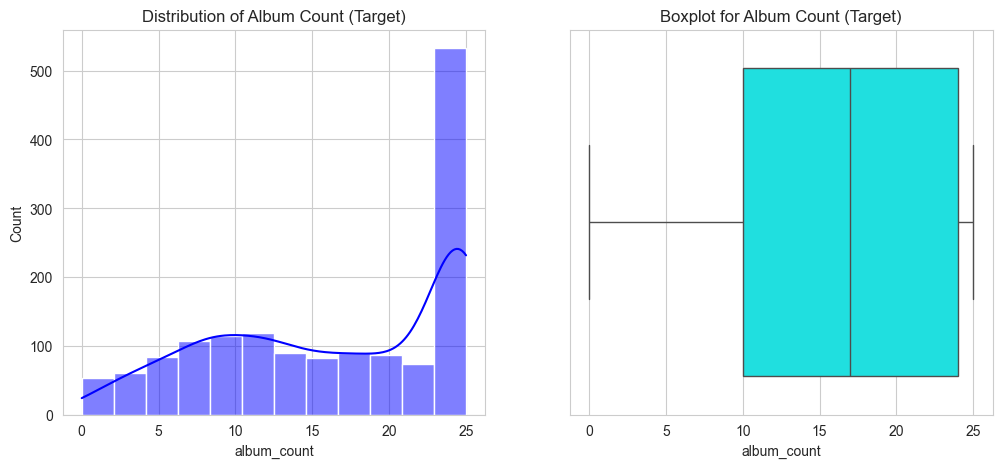

In [3]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['album_count'], kde = True, color = 'blue')
plt.title('Distribution of Album Count (Target)')

plt.subplot(1, 2, 2)
sns.boxplot(x = df_clean['album_count'], color = 'cyan')
plt.title('Boxplot for Album Count (Target)')

plt.show()

In [4]:
df_clean['album_count'].describe()

count    1488.000000
mean       16.351478
std         7.704232
min         0.000000
25%        10.000000
50%        17.000000
75%        24.000000
max        25.000000
Name: album_count, dtype: float64

### Univariate Analysis

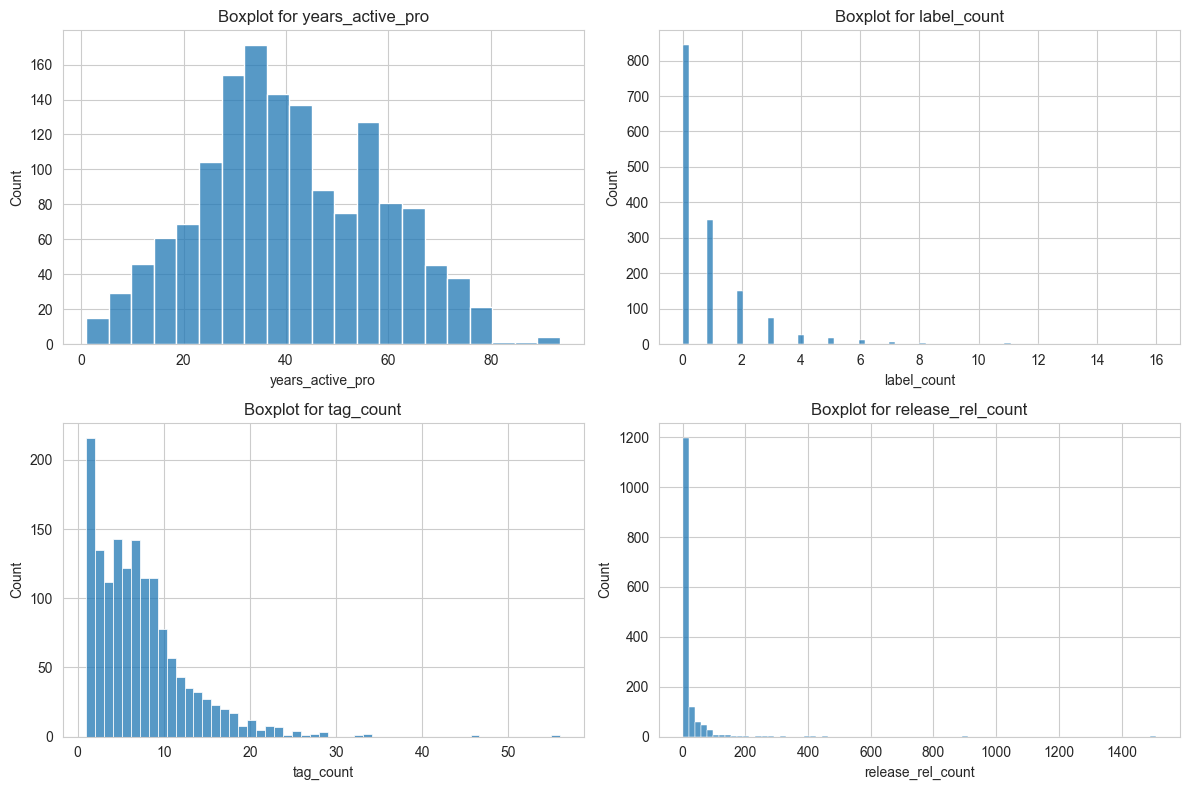

In [19]:
num_features = ['years_active_pro', 'label_count', 'tag_count', 'release_rel_count']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(x = df_clean[col])
    plt.title(f'Histogram for {col}')
plt.tight_layout()
plt.show()

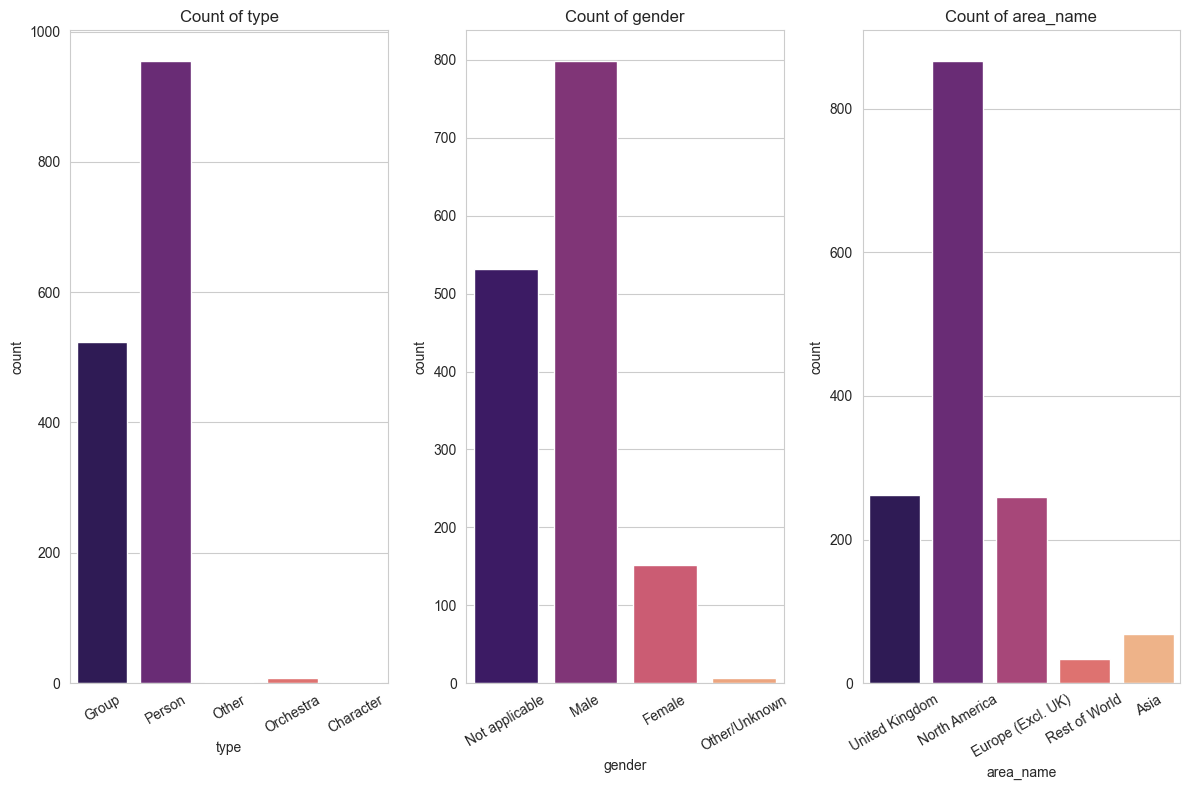

In [15]:
cat_features = ['type', 'gender', 'area_name']

plt.figure(figsize = (12, 8))
for i, col in enumerate(cat_features):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x = df_clean[col], palette = 'magma', hue = df_clean[col], legend = False)
    plt.title(f'Count of {col}')
    plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

In [21]:
df_clean['type'] = df_clean['type'].replace({'Orchestra' : 'Group', 'Character' : 'Person'})
df_clean['gender'] = df_clean['gender'].replace({'Other/Unknown': 'Not applicable'})
df_clean['area_name'] = df_clean['area_name'].replace({'Asia': 'Rest of World'})

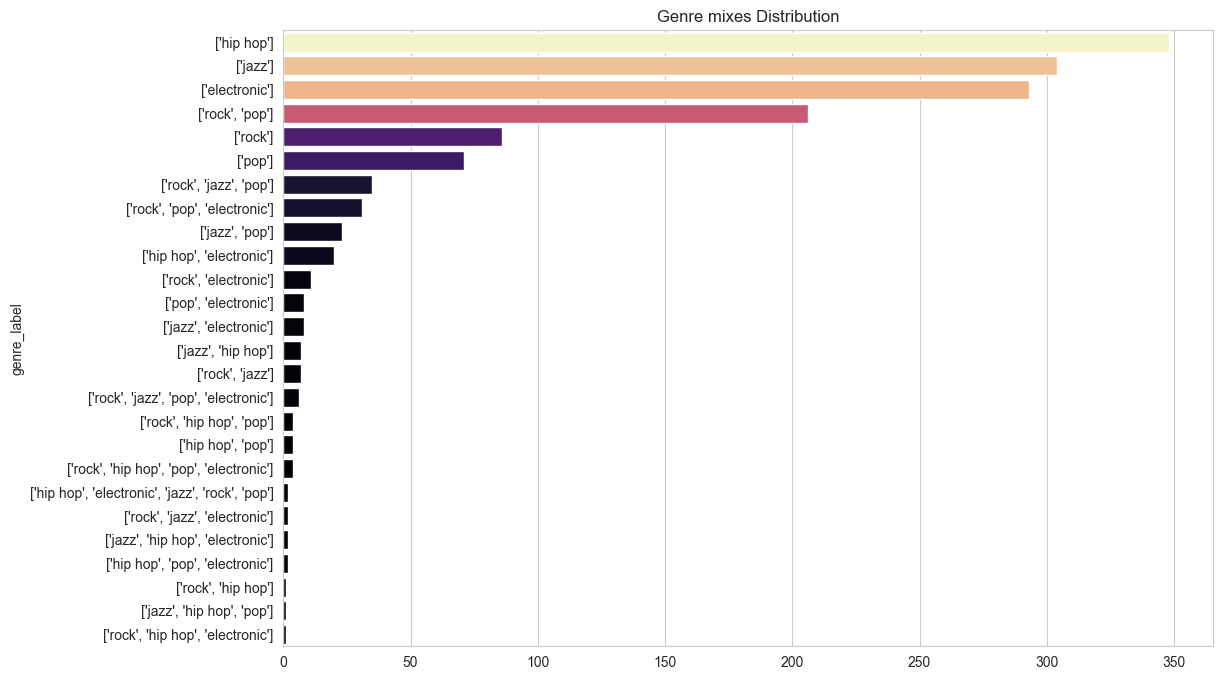

In [30]:
genres_exploded = df_clean.explode('genre_label')
genres_counts = genres_exploded['genre_label'].value_counts()

plt.figure(figsize = (12, 8))
sns.barplot(x = genres_counts.values, y = genres_counts.index, palette = 'magma', hue = genres_counts.values, legend = False)
plt.title('Genre mixes Distribution')
plt.show()

### Bivariate Analysis

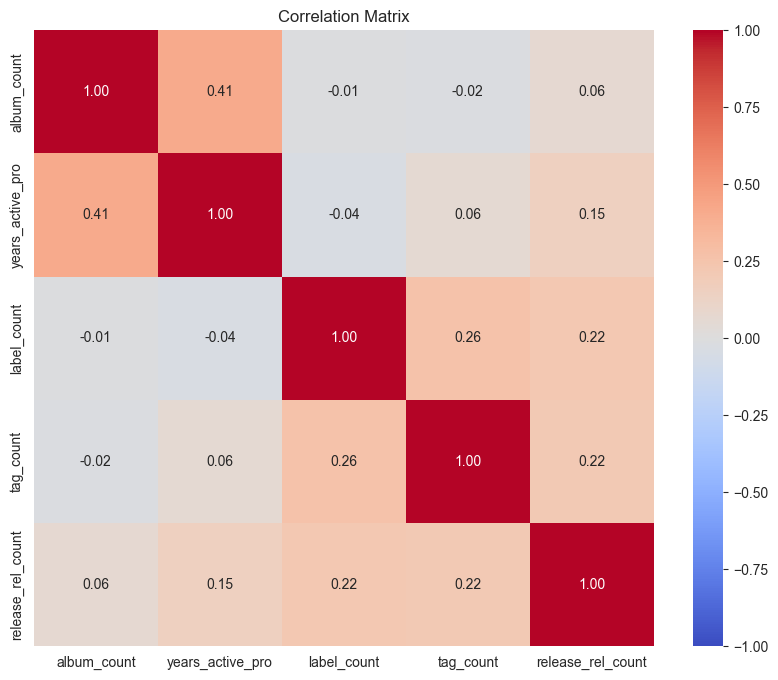

In [22]:
numeric_df = df_clean.select_dtypes(include = ['float64', 'int64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '.2f', vmin = -1, vmax = 1)
plt.title('Correlation Matrix')
plt.show()

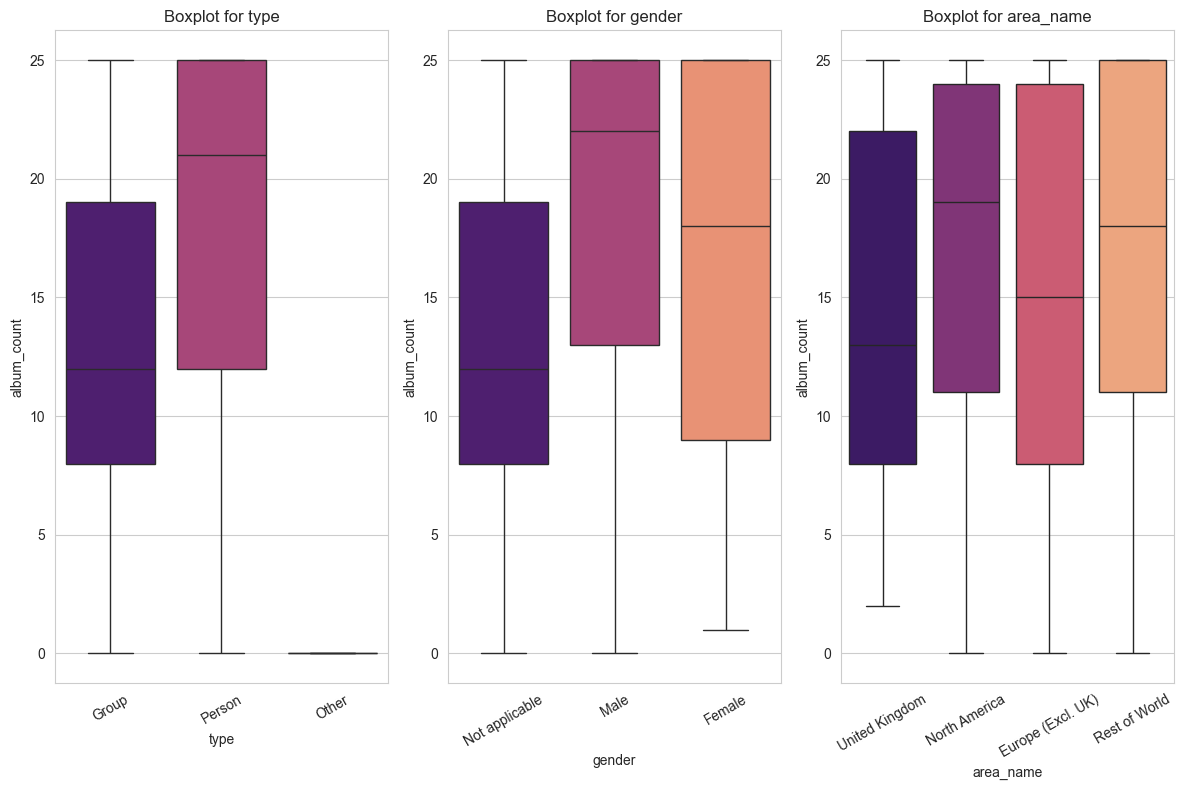

In [27]:
plt.figure(figsize = (12, 8))
for i, col in enumerate(cat_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x = col, y = 'album_count', data = df_clean, palette = 'magma', hue = col, legend = False)
    plt.title(f'Boxplot for {col}')
    plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

In [28]:
df_clean = df_clean[df_clean['type'] != 'Other'].copy()

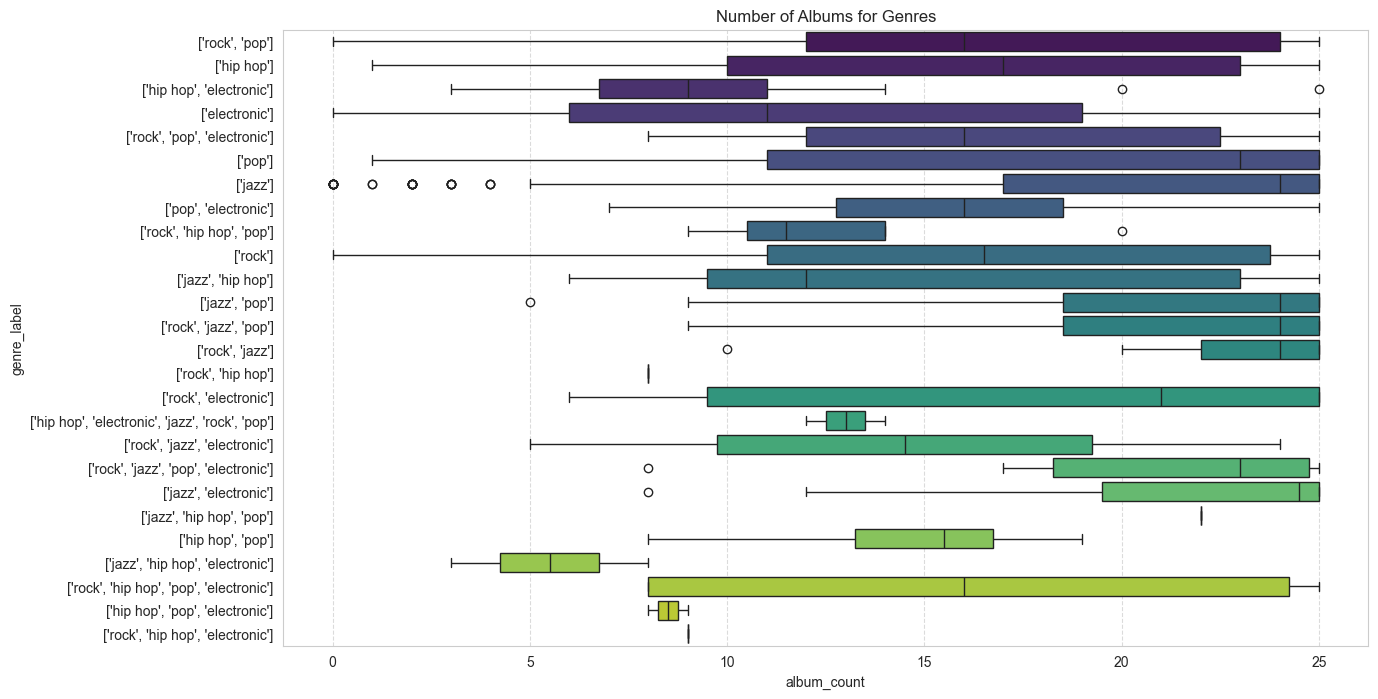

In [37]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=genres_exploded, x='album_count', y='genre_label', palette='viridis', hue = 'genre_label', legend = False)
plt.title('Number of Albums for Genres')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [35]:
df_clean.to_csv('final_df.csv', index = False)